In [15]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor



C:\Users\Hp\AppData\Local\Temp\ipykernel_18968\3813722297.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["fuel_type"].fillna(df["fuel_type"].mode()[0], inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_18968\3813722297.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop


 results: 
mean squared error:  714391936.0
R2 score:  0.943558931350708


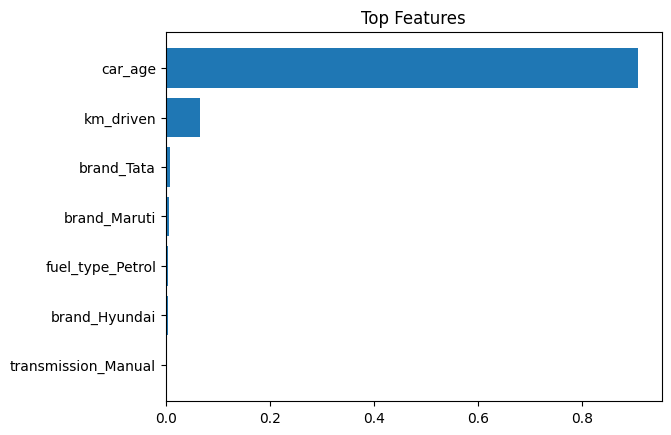

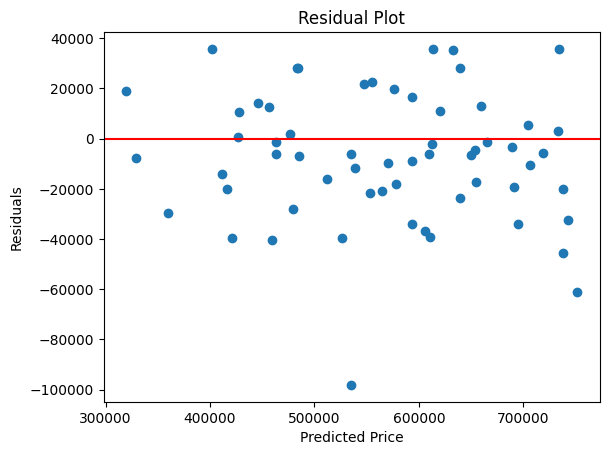

In [17]:
df  =pd.read_csv("vechicle_price_pred.csv")

# print(df.head())
# print(df.info())
# print(df.columns)


# handling missing values 

df.isnull().sum()

df.rename(columns={"mileage": "km_driven"}, inplace=True)


df["fuel_type"].fillna(df["fuel_type"].mode()[0], inplace=True)

df["transmission"].fillna(df["transmission"].mode()[0], inplace=True)

df["km_driven"].fillna(df["km_driven"].median(), inplace=True)

# feature engineering

current_year = 2026

df['car_age'] = current_year - df['year']

df.drop('year', axis=1, inplace=True)

df = pd.get_dummies(df, columns=['fuel_type', 'brand', 'transmission'], drop_first=True)

X = df.drop('price', axis=1)
y = df['price']

scalar = StandardScaler()

X_scaled = scalar.fit_transform(X)


X = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=3)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n results: ")
print("mean squared error: ", mse)
print("R2 score: ", r2)


importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(feat_imp['Feature'][:10], feat_imp['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()


residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red")
plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()
